# Personal Information
Name: **Alexandra Holíková**

StudentID: **14236788**

Email: [**alexandra.holikova@student.uva.nl**](alexandra.holikova@student.uva.nl)

Submitted on: **23.03.2026**

Github link: https://github.com/alexandraholik/MSc_Thesis.git

# Data Context

This EDA explores the **ParlaMint-NL-en** corpus (v5.0), an English-translated and 
linguistically annotated collection of Dutch parliamentary debates. The data comes from 
the Tweede Kamer (Lower House) and Eerste Kamer (Upper House), covering sessions from 
2014 to 2022. It is publicly available via CLARIN (http://hdl.handle.net/11356/2006).

The corpus consists of two file types we work with: **(1) metadata TSV files** — one row 
per utterance with speaker name, party, political orientation, gender, and debate topic — 
and **(2) plain-text debate files** — each line is a tab-separated utterance ID and speech 
text. The research goal is to detect stance-aware quote distortion in parliamentary debates, 
so we pay particular attention to party orientation, coalition/opposition status, and 
utterance-level text properties.


In [17]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

### Data Loading

We use `glob` to recursively find all `*meta.tsv` and `*.txt` debate files across all 
year subfolders under `ParlaMint-NL-en/ParlaMint-NL-en.txt/`. Both are loaded and 
concatenated, then merged on utterance ID.


In [18]:
BASE_DIR = "ParlaMint-NL-en/ParlaMint-NL-en.txt"

# Load regular meta files (speaker, party, topic info)
meta_files = glob.glob(os.path.join(BASE_DIR, "**", "*meta.tsv"), recursive=True)
meta_files = [f for f in meta_files if "ana-meta" not in f]  # exclude ana-meta
print(f"Found {len(meta_files)} regular meta files")

dfs = []
for f in meta_files:
    dfs.append(pd.read_csv(f, sep="\t"))
meta = pd.concat(dfs, ignore_index=True)
print(f"Regular meta shape: {meta.shape}")

# Load ana-meta files (sentiment, token counts)
ana_files = glob.glob(os.path.join(BASE_DIR, "**", "*ana-meta.tsv"), recursive=True)
print(f"Found {len(ana_files)} ana-meta files")

ana_dfs = []
for f in ana_files:
    ana_dfs.append(pd.read_csv(f, sep="\t"))
ana = pd.concat(ana_dfs, ignore_index=True)
print(f"Ana-meta shape: {ana.shape}")

# Join on utterance ID
meta = meta.merge(ana[["ID", "Senti_3", "Senti_6", "Senti_n", "Words", "Tokens", "Sents", "Names"]],
                  on="ID", how="left")
print(f"Combined shape: {meta.shape}")
meta.head(3)

Found 6100 regular meta files
Regular meta shape: (609209, 24)
Found 6100 ana-meta files
Ana-meta shape: (5028032, 12)
Combined shape: (609209, 31)


,Text_ID,ID,Title,Date,Body,Term,Session,Meeting,Sitting,Agenda,Subcorpus,Lang,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth,Topic,Senti_3,Senti_6,Senti_n,Words,Tokens,Sents,Names
0,ParlaMint-NL-en_2014-12-15-eerstekamer-4,ParlaMint-NL_2014-12-15-eerstekamer-4.u1,"Report of the meeting of the Dutch Upper House, Meeting 13, Session 4 (2014-...",2014-12-15,Upper house,Meeting of the 34th Eerste Kamer,Session 4,Meeting 13,Sitting 2014-12-15,-,Reference,English,Chairperson,MP,notMinister,VVD,Volkspartij voor Vrijheid en Democratie,Coalition,Centre-right,AnkieBroekers-Knol,"Broekers-Knol, Ankie",F,1946,Macroeconomics,-,-,-,15,16,1,2
1,ParlaMint-NL-en_2014-12-15-eerstekamer-4,ParlaMint-NL_2014-12-15-eerstekamer-4.u2,"Report of the meeting of the Dutch Upper House, Meeting 13, Session 4 (2014-...",2014-12-15,Upper house,Meeting of the 34th Eerste Kamer,Session 4,Meeting 13,Sitting 2014-12-15,-,Reference,English,Regular,notMP,notMinister,CDA,Christen-Democratisch Appèl,-,Centre to centre-right,PeterEssers,"Essers, Peter",M,1957,Macroeconomics,-,-,-,1219,1345,49,29
2,ParlaMint-NL-en_2014-12-15-eerstekamer-4,ParlaMint-NL_2014-12-15-eerstekamer-4.u3,"Report of the meeting of the Dutch Upper House, Meeting 13, Session 4 (2014-...",2014-12-15,Upper house,Meeting of the 34th Eerste Kamer,Session 4,Meeting 13,Sitting 2014-12-15,-,Reference,English,Regular,notMP,notMinister,SP,Socialistische Partij,Opposition,Left,GeertReuten,"Reuten, Geert",M,1946,Macroeconomics,-,-,-,26,29,2,4


In [19]:
# Check what columns the ana-meta files actually have
print(meta.columns.tolist())
# Check the first few rows to see what's there
meta.head(2)

['Text_ID', 'ID', 'Title', 'Date', 'Body', 'Term', 'Session', 'Meeting', 'Sitting', 'Agenda', 'Subcorpus', 'Lang', 'Speaker_role', 'Speaker_MP', 'Speaker_minister', 'Speaker_party', 'Speaker_party_name', 'Party_status', 'Party_orientation', 'Speaker_ID', 'Speaker_name', 'Speaker_gender', 'Speaker_birth', 'Topic', 'Senti_3', 'Senti_6', 'Senti_n', 'Words', 'Tokens', 'Sents', 'Names']


,Text_ID,ID,Title,Date,Body,Term,Session,Meeting,Sitting,Agenda,Subcorpus,Lang,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth,Topic,Senti_3,Senti_6,Senti_n,Words,Tokens,Sents,Names
0,ParlaMint-NL-en_2014-12-15-eerstekamer-4,ParlaMint-NL_2014-12-15-eerstekamer-4.u1,"Report of the meeting of the Dutch Upper House, Meeting 13, Session 4 (2014-...",2014-12-15,Upper house,Meeting of the 34th Eerste Kamer,Session 4,Meeting 13,Sitting 2014-12-15,-,Reference,English,Chairperson,MP,notMinister,VVD,Volkspartij voor Vrijheid en Democratie,Coalition,Centre-right,AnkieBroekers-Knol,"Broekers-Knol, Ankie",F,1946,Macroeconomics,-,-,-,15,16,1,2
1,ParlaMint-NL-en_2014-12-15-eerstekamer-4,ParlaMint-NL_2014-12-15-eerstekamer-4.u2,"Report of the meeting of the Dutch Upper House, Meeting 13, Session 4 (2014-...",2014-12-15,Upper house,Meeting of the 34th Eerste Kamer,Session 4,Meeting 13,Sitting 2014-12-15,-,Reference,English,Regular,notMP,notMinister,CDA,Christen-Democratisch Appèl,-,Centre to centre-right,PeterEssers,"Essers, Peter",M,1957,Macroeconomics,-,-,-,1219,1345,49,29


In [20]:
# Grab all .txt debate files across all year subfolders
# Exclude the 00README.txt file
txt_files = [
    f for f in glob.glob(os.path.join(BASE_DIR, "**", "*.txt"), recursive=True)
    if "README" not in f
]
print(f"Found {len(txt_files)} text files")

utterances = []
for f in txt_files:
    with open(f, "r", encoding="utf-8") as fh:
        for line in fh:
            line = line.strip()
            if "\t" in line:
                uid, text = line.split("\t", 1)
                utterances.append({"ID": uid, "text": text})

txt_df = pd.DataFrame(utterances)
print(f"Text utterances shape: {txt_df.shape}")
txt_df.head(3)

Found 6100 text files
Text utterances shape: (609209, 2)


,ID,text
0,ParlaMint-NL_2014-12-16-eerstekamer-2.u1,I would like to welcome the Minister of the Interior and Kingdom Relations t...
1,ParlaMint-NL_2014-12-16-eerstekamer-2.u2,Mr. Chairman. We are talking today about the legislative proposal aimed at a...
2,ParlaMint-NL_2014-12-16-eerstekamer-2.u3,Mr. Chairman. We have before us a legislative proposal dealing with two issu...


In [21]:
# See what electoral terms are available
print(meta["Term"].value_counts())

Term
Meeting of the 29th Tweede Kamer    321151
Meeting of the 28th Tweede Kamer    176040
Meeting of the 36th Eerste Kamer     42304
Meeting of the 30th Tweede Kamer     35050
Meeting of the 35th Eerste Kamer     30875
Meeting of the 34th Eerste Kamer      3789
Name: count, dtype: int64


### Selecting the Electoral Term: 29th Tweede Kamer (2017–2021)

For this analysis we focus on the **29th Tweede Kamer**, the most recent complete 
electoral term in the corpus. It covers the period from **2017 to 2021** under the 
Rutte III and Rutte IV cabinets, a four-party coalition of VVD, CDA, D66, and 
ChristenUnie.

This term was selected for three reasons:
1. **Size**: with 321,151 utterances it is the largest single term in the corpus, 
   providing sufficient data for robust modelling
2. **Recency**: it is the most politically current complete term, making findings 
   more relevant to contemporary Dutch parliamentary discourse
3. **Natural split**: it spans both the pre-COVID reference subcorpus (up to 
   September 2019) and the COVID subcorpus (October 2019 onwards), offering a 
   built-in contrastive dimension if needed

The Eerste Kamer terms (35th, 36th) are excluded as our research focuses on 
Lower House debate dynamics where coalition/opposition stance contrasts are 
most pronounced.


In [22]:
# Filter metadata to 29th Tweede Kamer
TERM = "Meeting of the 29th Tweede Kamer"

meta_filtered = meta[meta["Term"] == TERM].copy()
print(f"Filtered metadata shape: {meta_filtered.shape}")
print(f"Date range: {meta_filtered['Date'].min()} → {meta_filtered['Date'].max()}")

# Merge with text utterances
df = meta_filtered.merge(txt_df, on="ID", how="left")

print(f"\nMerged shape:           {df.shape}")
print(f"Rows with text matched: {df['text'].notna().sum()}")
print(f"Rows without text:      {df['text'].isna().sum()}")

df.head(3)

Filtered metadata shape: (321151, 31)
Date range: 2017-10-31 → 2021-12-21

Merged shape:           (321151, 32)
Rows with text matched: 321151
Rows without text:      0


,Text_ID,ID,Title,Date,Body,Term,Session,Meeting,Sitting,Agenda,Subcorpus,Lang,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth,Topic,Senti_3,Senti_6,Senti_n,Words,Tokens,Sents,Names,text
0,ParlaMint-NL-en_2017-12-21-tweedekamer-7,ParlaMint-NL_2017-12-21-tweedekamer-7.u1,"Report of the meeting of the Dutch Lower House, Meeting 38, Session 7 (2017-...",2017-12-21,Lower house,Meeting of the 29th Tweede Kamer,Session 7,Meeting 38,Sitting 2017-12-21,-,Reference,English,Chairperson,MP,notMinister,PvdA,Partij van de Arbeid,-,Centre-left,KhadijaArib,"Arib, Khadija",F,1960,Mix,-,-,-,69,80,7,6,We continue with the VAO Labour Market in healthcare. A warm word of welcome...
1,ParlaMint-NL-en_2017-12-21-tweedekamer-7,ParlaMint-NL_2017-12-21-tweedekamer-7.u2,"Report of the meeting of the Dutch Lower House, Meeting 38, Session 7 (2017-...",2017-12-21,Lower house,Meeting of the 29th Tweede Kamer,Session 7,Meeting 38,Sitting 2017-12-21,-,Reference,English,Regular,notMP,notMinister,PVV,Partij voor de Vrijheid,Opposition,Right to far-right,GidiMarkuszower,"Markuszower, Gidi",M,1977,Other,-,-,-,30,37,4,2,"That's right, Mr. Chairman. Thank you. Indeed, on behalf of Mrs Agema, I wou..."
2,ParlaMint-NL-en_2017-12-21-tweedekamer-7,ParlaMint-NL_2017-12-21-tweedekamer-7.u3,"Report of the meeting of the Dutch Lower House, Meeting 38, Session 7 (2017-...",2017-12-21,Lower house,Meeting of the 29th Tweede Kamer,Session 7,Meeting 38,Sitting 2017-12-21,-,Reference,English,Regular,notMP,notMinister,PVV,Partij voor de Vrijheid,Opposition,Right to far-right,GidiMarkuszower,"Markuszower, Gidi",M,1977,Other,-,-,-,4,5,1,0,"The second motion is: [[Motion]] [[The Chamber,]] [[heard the debate,]] [[ca..."


### Analysis 1: Corpus Overview

We start with a high-level inspection of the dataset: its shape, variable types, 
and missing values. This tells us what we're working with before doing any deeper analysis.


In [23]:
# Shape
print(f"Rows (utterances): {df.shape[0]:,}")
print(f"Columns (variables): {df.shape[1]}")

# Variable types
print("\nColumn types:")
print(df.dtypes)

# Missing values
print("\nMissing values per column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).sort_values("missing_%", ascending=False)

print(missing_report[missing_report["missing_count"] > 0])

Rows (utterances): 321,151
Columns (variables): 32

Column types:
Text_ID               object
ID                    object
Title                 object
Date                  object
Body                  object
Term                  object
Session               object
Meeting               object
Sitting               object
Agenda                object
Subcorpus             object
Lang                  object
Speaker_role          object
Speaker_MP            object
Speaker_minister      object
Speaker_party         object
Speaker_party_name    object
Party_status          object
Party_orientation     object
Speaker_ID            object
Speaker_name          object
Speaker_gender        object
Speaker_birth         object
Topic                 object
Senti_3               object
Senti_6               object
Senti_n               object
Words                 object
Tokens                object
Sents                 object
Names                 object
text                  object
dtype:

### Data Type Cleaning

All columns were loaded as strings from the TSV files. We cast dates, numeric 
linguistic annotations, and categorical columns to their appropriate types.


In [24]:
# Datetime
df["Date"] = pd.to_datetime(df["Date"])

# Numeric columns
numeric_cols = ["Words", "Tokens", "Sents", "Names", "Senti_n"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Categorical columns (saves memory too)
cat_cols = ["Speaker_party", "Speaker_gender", "Party_status", 
            "Party_orientation", "Topic", "Subcorpus", 
            "Speaker_role", "Speaker_MP", "Speaker_minister"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Confirm
print(df.dtypes)
print(f"\nDate range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nWords stats:\n{df['Words'].describe().round(1)}")

Text_ID                       object
ID                            object
Title                         object
Date                  datetime64[ns]
Body                          object
Term                          object
Session                       object
Meeting                       object
Sitting                       object
Agenda                        object
Subcorpus                   category
Lang                          object
Speaker_role                category
Speaker_MP                  category
Speaker_minister            category
Speaker_party               category
Speaker_party_name            object
Party_status                category
Party_orientation           category
Speaker_ID                    object
Speaker_name                  object
Speaker_gender              category
Speaker_birth                 object
Topic                       category
Senti_3                       object
Senti_6                       object
Senti_n                      float64
W

In [25]:
# Datetime
df["Date"] = pd.to_datetime(df["Date"])

# Numeric columns
numeric_cols = ["Words", "Tokens", "Sents", "Names", "Senti_n"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Categorical columns (saves memory too)
cat_cols = ["Speaker_party", "Speaker_gender", "Party_status",
            "Party_orientation", "Topic", "Subcorpus",
            "Speaker_role", "Speaker_MP", "Speaker_minister",
            "Senti_3", "Senti_6"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Speaker birth year as numeric
df["Speaker_birth"] = pd.to_numeric(df["Speaker_birth"], errors="coerce")

# Confirm
print(df.dtypes)
print(f"\nDate range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nWords stats:\n{df['Words'].describe().round(1)}")
print(f"\nSenti_3 values: {df['Senti_3'].cat.categories.tolist()}")
print(f"Senti_6 values: {df['Senti_6'].cat.categories.tolist()}")
print(f"Speaker_birth range: {df['Speaker_birth'].min():.0f} – {df['Speaker_birth'].max():.0f}")


Text_ID                       object
ID                            object
Title                         object
Date                  datetime64[ns]
Body                          object
Term                          object
Session                       object
Meeting                       object
Sitting                       object
Agenda                        object
Subcorpus                   category
Lang                          object
Speaker_role                category
Speaker_MP                  category
Speaker_minister            category
Speaker_party               category
Speaker_party_name            object
Party_status                category
Party_orientation           category
Speaker_ID                    object
Speaker_name                  object
Speaker_gender              category
Speaker_birth                float64
Topic                       category
Senti_3                     category
Senti_6                     category
Senti_n                      float64
W

### Analysis 2: Utterance Length Distribution

We examine the distribution of utterance lengths (in words) to understand 
the nature of parliamentary turns. This is critical for downstream modelling 
decisions such as truncation thresholds for transformer-based models.


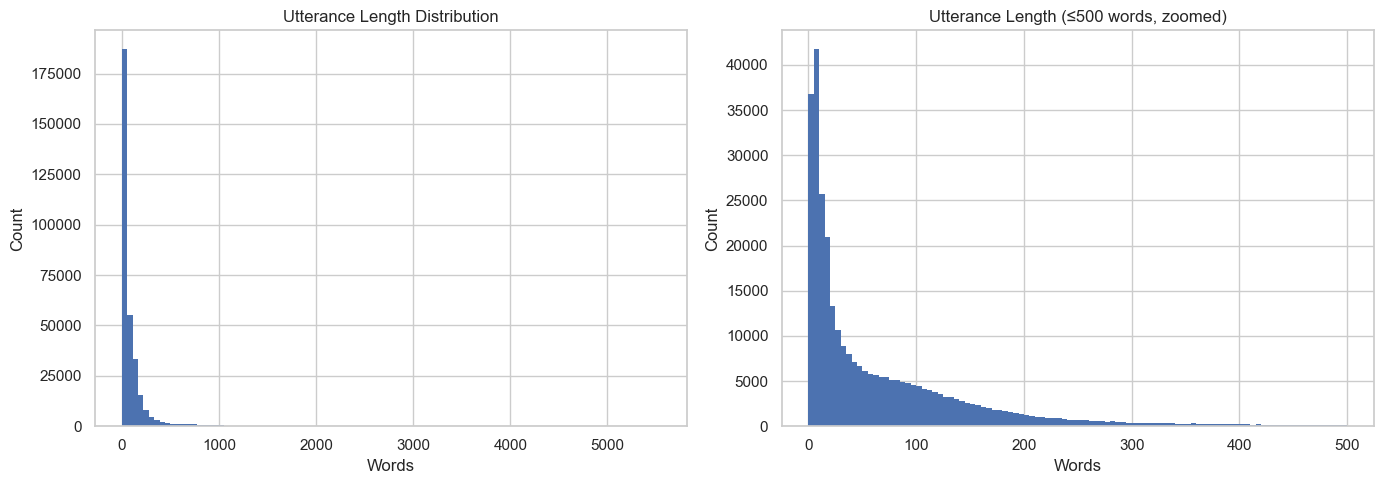

Utterances ≤ 10 words (likely procedural): 84,338 (26.3%)
Utterances > 512 words (exceeds BERT limit): 10,695 (3.3%)


In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full distribution
axes[0].hist(df["Words"], bins=100, color="#4C72B0", edgecolor="none")
axes[0].set_title("Utterance Length Distribution")
axes[0].set_xlabel("Words")
axes[0].set_ylabel("Count")

# Right: zoomed to 0–500 words (captures ~95% of data)
axes[1].hist(df[df["Words"] <= 500]["Words"], bins=100, color="#4C72B0", edgecolor="none")
axes[1].set_title("Utterance Length (≤500 words, zoomed)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("utterance_length.png", dpi=150)
plt.show()

print(f"Utterances ≤ 10 words (likely procedural): {(df['Words'] <= 10).sum():,} ({(df['Words'] <= 10).mean()*100:.1f}%)")
print(f"Utterances > 512 words (exceeds BERT limit): {(df['Words'] > 512).sum():,} ({(df['Words'] > 512).mean()*100:.1f}%)")

- 26.3% of utterances (84,338) are ≤10 words — these are mostly procedural turns by the chair ("Thank you", "The floor is yours", etc.)
- Only 3.3% exceed 512 tokens — meaning the vast majority of speeches fit within BERT's context window without truncation, which is good news for your modelling
- Heavy right skew — median 36 words vs mean 97 words

### Analysis 3: Party Distribution

We examine the distribution of utterances across political parties. 
Class imbalance here has direct implications for model training — 
parties with very few utterances may need to be grouped or excluded.


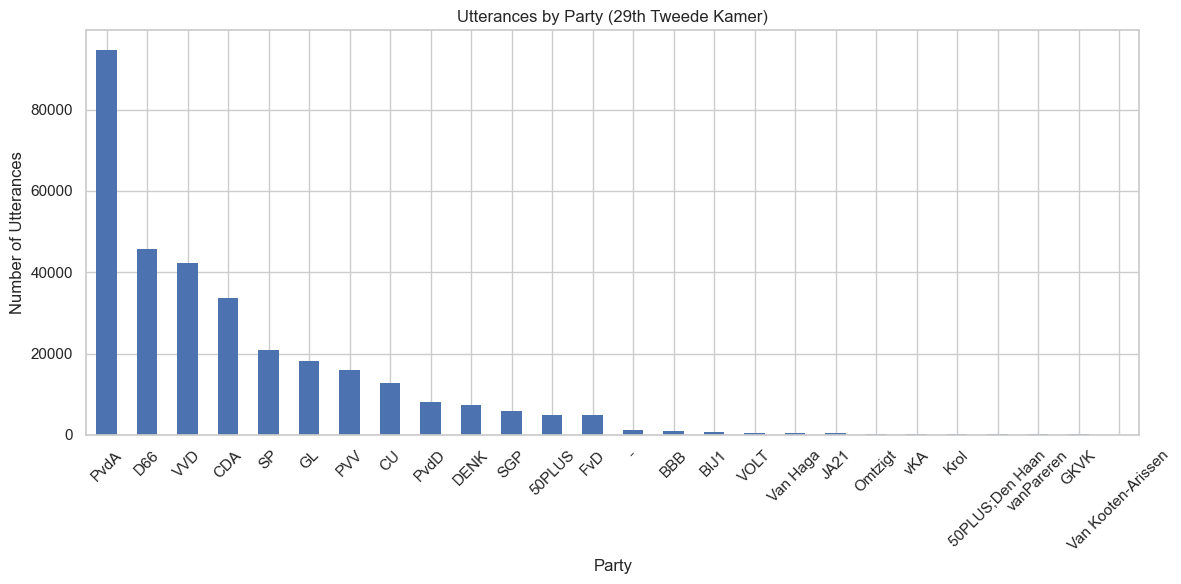

Speaker_party
PvdA                  94718
D66                   45652
VVD                   42347
CDA                   33582
SP                    20826
GL                    18182
PVV                   16084
CU                    12848
PvdD                   8205
DENK                   7289
SGP                    5953
50PLUS                 5005
FvD                    4864
-                      1161
BBB                    1036
BIJ1                    642
VOLT                    506
Van Haga                502
JA21                    426
Omtzigt                 340
vKA                     311
Krol                    183
50PLUS;Den Haan         146
vanPareren              136
GKVK                    129
Van Kooten-Arissen       78
Name: count, dtype: int64

Total parties: 26


In [27]:
party_counts = df["Speaker_party"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
party_counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="none")
ax.set_title("Utterances by Party (29th Tweede Kamer)")
ax.set_xlabel("Party")
ax.set_ylabel("Number of Utterances")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("party_distribution.png", dpi=150)
plt.show()

print(party_counts)
print(f"\nTotal parties: {df['Speaker_party'].nunique()}")

- PvdA dominates with 94,718 utterances — almost 3× D66 (2nd). This is because the chair (Khadija Arib, PvdA) generates thousands of short procedural turns. This is a major bias to address.
- 13 parties have <1,000 utterances — these are splinter/individual parties that formed mid-term (Omtzigt, VOLT, BIJ1, etc.) and will need to be grouped as "Other" for modelling.

### Analysis 4: Coalition vs. Opposition & Party Status

The `Party_status` column distinguishes coalition, opposition, and other roles.
This is a key variable for stance detection since coalition parties tend to 
defend government policy while opposition parties tend to challenge it.


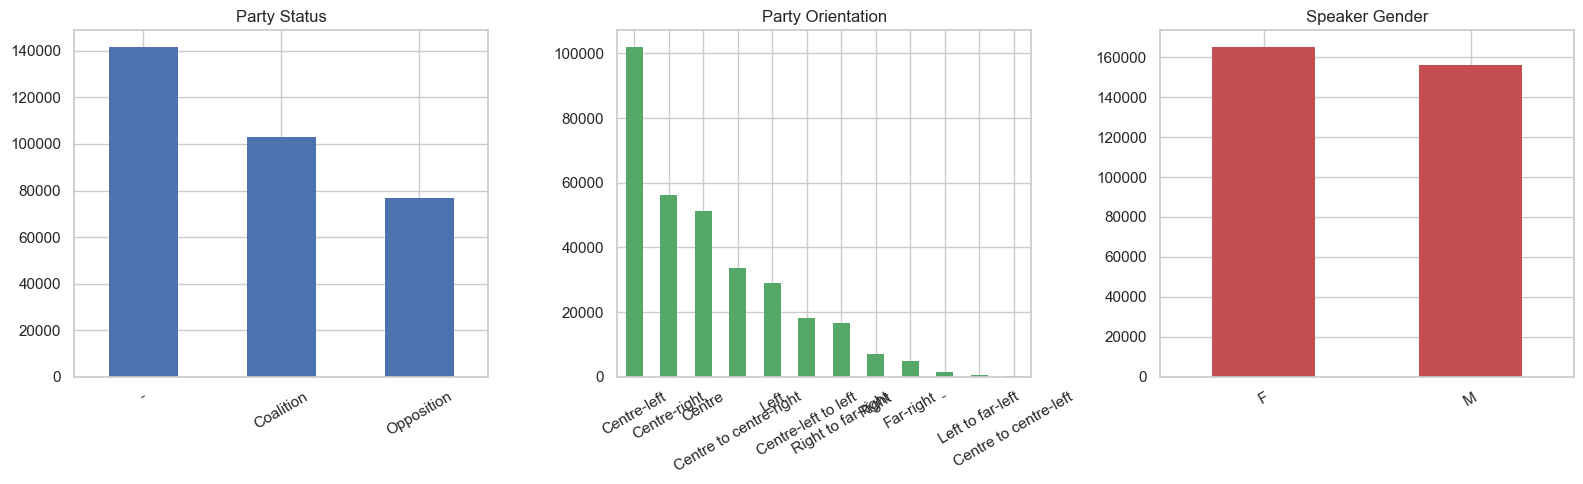

Party status:
 Party_status
-             141704
Coalition     102861
Opposition     76586
Name: count, dtype: int64

Party orientation:
 Party_orientation
Centre-left               102007
Centre-right               56231
Centre                     51309
Centre to centre-right     33765
Left                       29031
Centre-left to left        18182
Right to far-right         16646
Right                       6924
Far-right                   4864
-                           1472
Left to far-left             642
Centre to centre-left         78
Name: count, dtype: int64

Speaker gender:
 Speaker_gender
F    165171
M    155980
Name: count, dtype: int64


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Party status
df["Party_status"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0", edgecolor="none")
axes[0].set_title("Party Status")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# Plot 2: Party orientation
df["Party_orientation"].value_counts().plot(kind="bar", ax=axes[1], color="#55A868", edgecolor="none")
axes[1].set_title("Party Orientation")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

# Plot 3: Speaker gender
df["Speaker_gender"].value_counts().plot(kind="bar", ax=axes[2], color="#C44E52", edgecolor="none")
axes[2].set_title("Speaker Gender")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("party_status_orientation_gender.png", dpi=150)
plt.show()

print("Party status:\n", df["Party_status"].value_counts())
print("\nParty orientation:\n", df["Party_orientation"].value_counts())
print("\nSpeaker gender:\n", df["Speaker_gender"].value_counts())

- Party status: Coalition (~140k) > Other (~103k, mostly chair) > Opposition (~78k) — the large "Other" category is dominated by the chair role, which is important to filter when analysing substantive debate
- Party orientation: Corpus is left-leaning — Centre-left (100k) and Centre-right (77k) dominate; far-right (PVV, FvD) combined ~28k
- Speaker gender: Nearly balanced — F (165,171) vs M (155,980) — unusually equal for a parliament, again influenced by the female chair generating many turns

### Analysis 5: Topic Distribution

The `Topic` column reflects the policy domain of each debate session. 
Understanding topic coverage helps assess whether the corpus is broad 
enough for generalisation, or concentrated in specific policy areas.


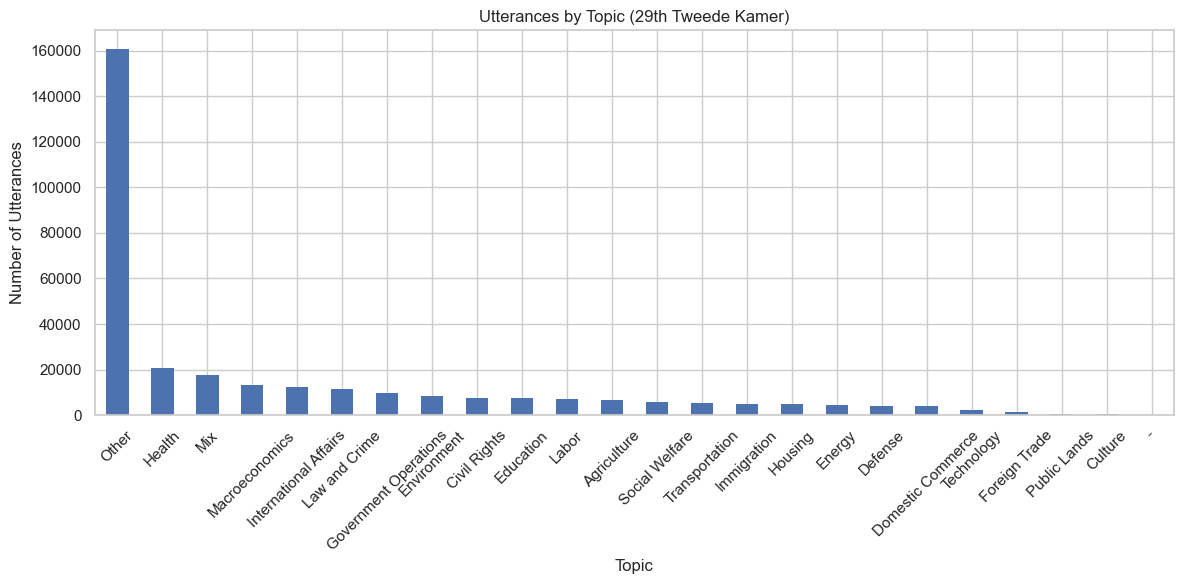

Topic
Other                    160807
Health                    20827
Mix                       17471
Macroeconomics            13223
International Affairs     12202
Law and Crime             11297
Government Operations      9757
Environment                8392
Civil Rights               7715
Education                  7670
Labor                      6948
Agriculture                6661
Social Welfare             5762
Transportation             5221
Immigration                5043
Housing                    5027
Energy                     4596
Defense                    4195
Domestic Commerce          4165
Technology                 2203
Foreign Trade              1317
Public Lands                342
Culture                     300
-                            10
Name: count, dtype: int64

Total topics: 24


In [29]:
topic_counts = df["Topic"].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
topic_counts.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="none")
ax.set_title("Utterances by Topic (29th Tweede Kamer)")
ax.set_xlabel("Topic")
ax.set_ylabel("Number of Utterances")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("topic_distribution.png", dpi=150)
plt.show()

print(topic_counts)
print(f"\nTotal topics: {df['Topic'].nunique()}")


- "Other" dominates massively (160,807 — 50% of all utterances), which is a known limitation of the CAP topic coding scheme used by ParlaMint — procedural debates and mixed sessions fall into "Other". 
- The remaining topics are well-distributed across 22 policy domains with Health, Mix, and Macroeconomics leading. Good coverage for generalisation.

### Analysis 6: Utterance Length by Party Status

We examine whether substantive speech length differs between coalition, 
opposition, and other speakers. We filter out utterances ≤10 words to 
exclude procedural chair turns before comparing distributions.


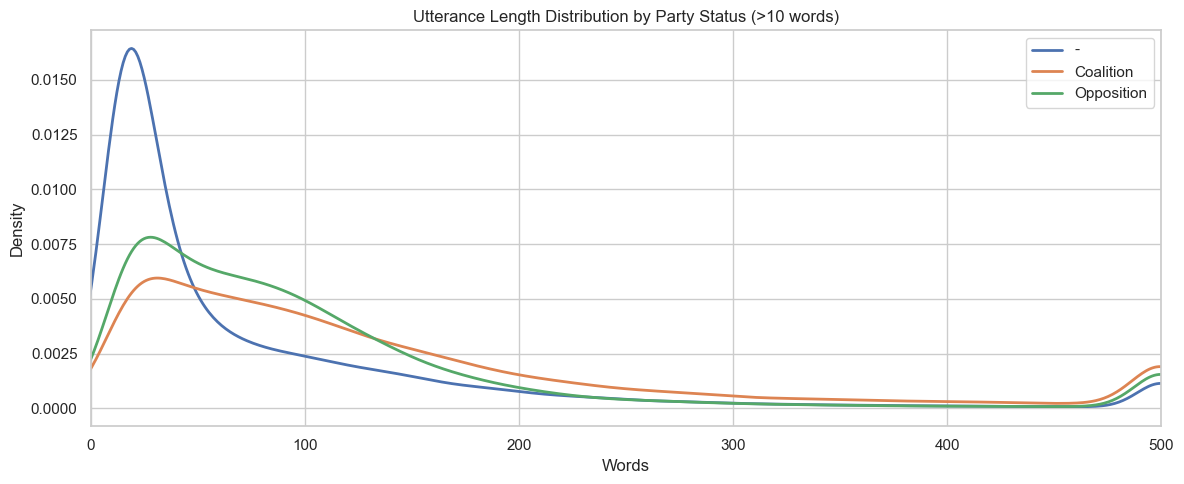

                count   mean    std   min   25%   50%    75%     max
Party_status                                                        
-             85403.0   92.8  185.6  11.0  17.0  34.0   98.0  4600.0
Coalition     88897.0  165.9  232.4  11.0  48.0  99.0  181.0  5169.0
Opposition    62513.0  130.6  230.9  11.0  37.0  76.0  129.0  5545.0


In [30]:
# Filter out procedural turns for fairer comparison
df_sub = df[df["Words"] > 10].copy()

fig, ax = plt.subplots(figsize=(12, 5))

for status, group in df_sub.groupby("Party_status", observed=True):
    group["Words"].clip(upper=500).plot.kde(ax=ax, label=str(status), linewidth=2)

ax.set_title("Utterance Length Distribution by Party Status (>10 words)")
ax.set_xlabel("Words")
ax.set_ylabel("Density")
ax.set_xlim(0, 500)
ax.legend()
plt.tight_layout()
plt.savefig("length_by_party_status.png", dpi=150)
plt.show()

print(df_sub.groupby("Party_status", observed=True)["Words"].describe().round(1))


- Coalition speakers (mean 165.9 words) speak significantly longer than opposition (130.6) and the "Other"/chair group (92.8).

### Analysis 7: Debate Activity Over Time

We plot monthly utterance counts over the 29th term to identify 
activity patterns and confirm the pre-COVID vs. COVID subcorpus split.


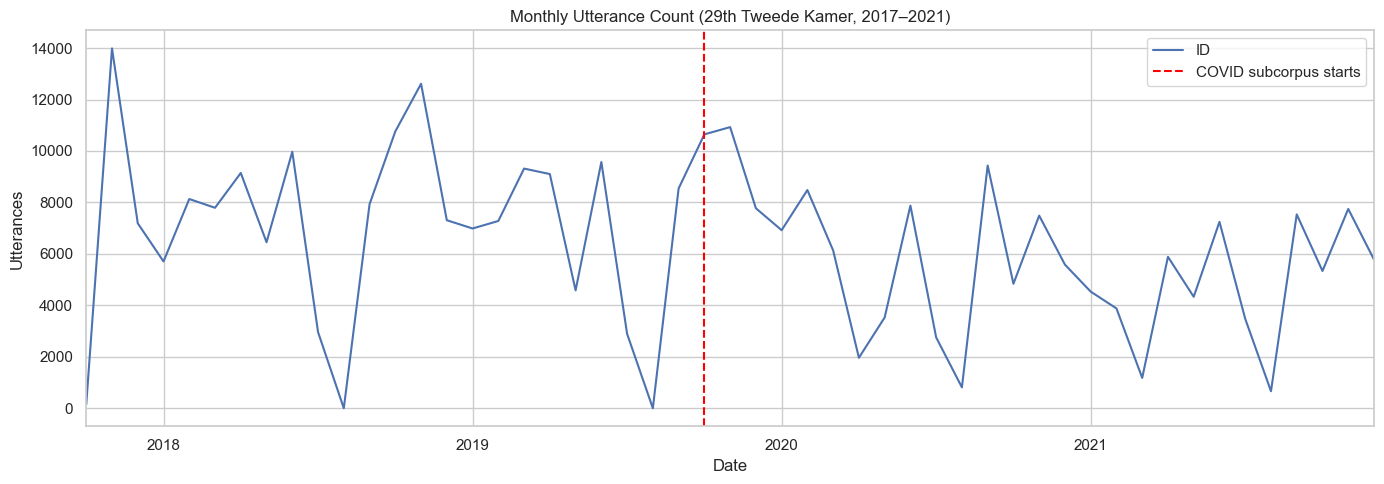

In [32]:
monthly = df.set_index("Date").resample("MS")["ID"].count()

fig, ax = plt.subplots(figsize=(14, 5))
monthly.plot(ax=ax, color="#4C72B0", linewidth=1.5)
ax.axvline(pd.Timestamp("2019-10-01"), color="red", linestyle="--", linewidth=1.5, label="COVID subcorpus starts")
ax.set_title("Monthly Utterance Count (29th Tweede Kamer, 2017–2021)")
ax.set_xlabel("Date")
ax.set_ylabel("Utterances")
ax.legend()
plt.tight_layout()
plt.savefig("utterances_over_time.png", dpi=150)
plt.show()


## Conclusions

This exploratory analysis of the 29th Tweede Kamer subcorpus (2017–2021) 
reveals several properties of the ParlaMint-NL-en dataset that directly 
inform subsequent modelling decisions.

**Corpus composition.** The dataset contains 321,151 utterances across 
26 parties, spanning a full electoral term from October 2017 to December 2021. 
All columns are complete with zero missing values after joining the regular 
and ana-meta files.

**Utterance length.** The distribution is heavily right-skewed (median: 36 
words, mean: 97 words). Approximately 26.3% of utterances contain ≤10 words 
and represent procedural chair turns with little semantic content. Only 3.3% 
exceed the 512-token BERT limit. For downstream modelling, utterances ≤10 
words should be filtered out, and truncation at 512 tokens will affect a 
negligible portion of the data.

**Party imbalance.** PvdA dominates with 94,718 utterances (~29%), largely 
due to the chair role (Khadija Arib). This is a label imbalance that must be 
addressed through stratified sampling or filtering by `Speaker_role` before 
training any party-level classifier.

**Coalition vs. opposition.** Coalition speakers produce longer utterances 
(mean: 165.9 words) compared to opposition speakers (mean: 130.6 words), 
suggesting that government defenders tend to give more elaborate speeches. 
The `Party_status` column provides a reliable binary signal for 
coalition/opposition stance that can serve as a weak supervision label.

**Topic coverage.** The corpus spans 23 policy topics, though 50% of 
utterances fall under "Other" — a known limitation of the CAP coding scheme. 
Substantive topics such as Health, Macroeconomics, and International Affairs 
are well-represented for topic-stratified analyses.

**Sentiment annotations.** The `Senti_3` and `Senti_6` columns are empty 
for the 29th term subcorpus and cannot be used as features or labels. 
Sentiment analysis would require external annotation.

**Limitations.** The corpus reflects translated English text, not the 
original Dutch, which may introduce translation artefacts. The dominance 
of the chair role inflates certain party and gender distributions. 
Splinter parties with fewer than 1,000 utterances (13 parties) should 
be grouped as "Other" for any classification task.
